# 06 — Strong lensing: SIE caustics, critical curves and image solver

Singular Isothermal Ellipsoid (Kormann+ 1994): closed-form deflection, caustics, critical lines, and a robust polar-angle root finder for the multi-image positions of a point source.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


## 1. Build the lens from a velocity dispersion

In [2]:
cosmo = gl.cosmology.Cosmology(H0=70., Om0=0.3)
sie = gl.lens.SIE.from_velocity_dispersion(
    sigma_v_kms=220., q=0.7, pa=np.pi/4, zl=0.3, zs=2.0, cosmo=cosmo,
)
print(f"theta_E = {float(sie.theta_E):.3f} arcsec")


theta_E = 1.074 arcsec


## 2. Caustics, critical curves, source and images

found 4 images


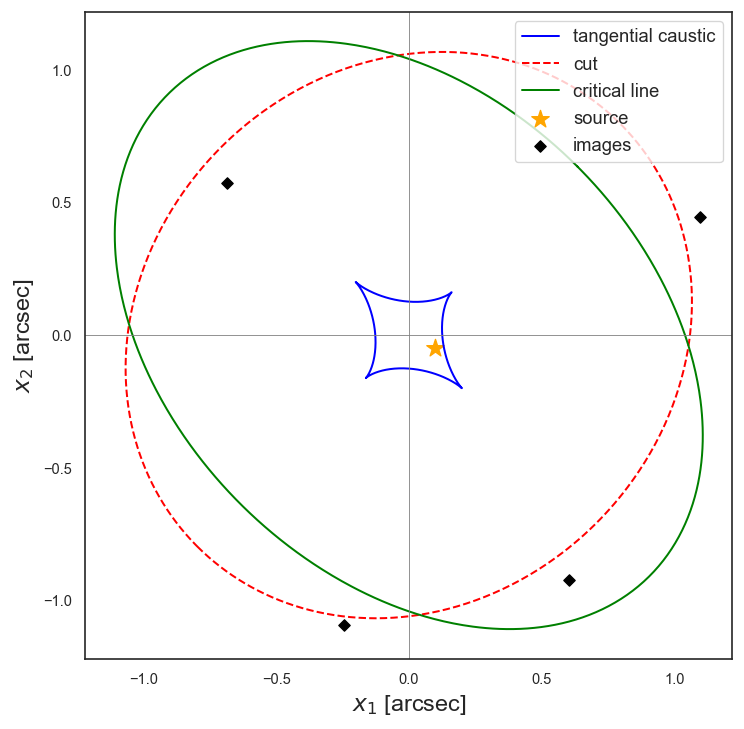

In [3]:
beta_x, beta_y = torch.tensor(0.10), torch.tensor(-0.05)

cau_x, cau_y = sie.tangential_caustic(n=600)
crit_x, crit_y = sie.tangential_critical(n=600)
cut_x, cut_y = sie.cut(n=600)
ximg, yimg = sie.solve_image_positions(beta_x, beta_y, n_grid=4000)
print(f"found {len(ximg)} images")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(cau_x, cau_y, 'b-', label='tangential caustic')
ax.plot(cut_x, cut_y, 'r--', label='cut')
ax.plot(crit_x, crit_y, 'g-', label='critical line')
ax.scatter(beta_x, beta_y, c='orange', marker='*', s=120, label='source')
ax.scatter(ximg, yimg, c='k', marker='D', label='images')
ax.axhline(0, color='gray', lw=.5); ax.axvline(0, color='gray', lw=.5)
ax.set_aspect('equal'); ax.legend()
ax.set(xlabel=r'$x_1$ [arcsec]', ylabel=r'$x_2$ [arcsec]')
plt.show()


## 3. Convergence and magnification maps

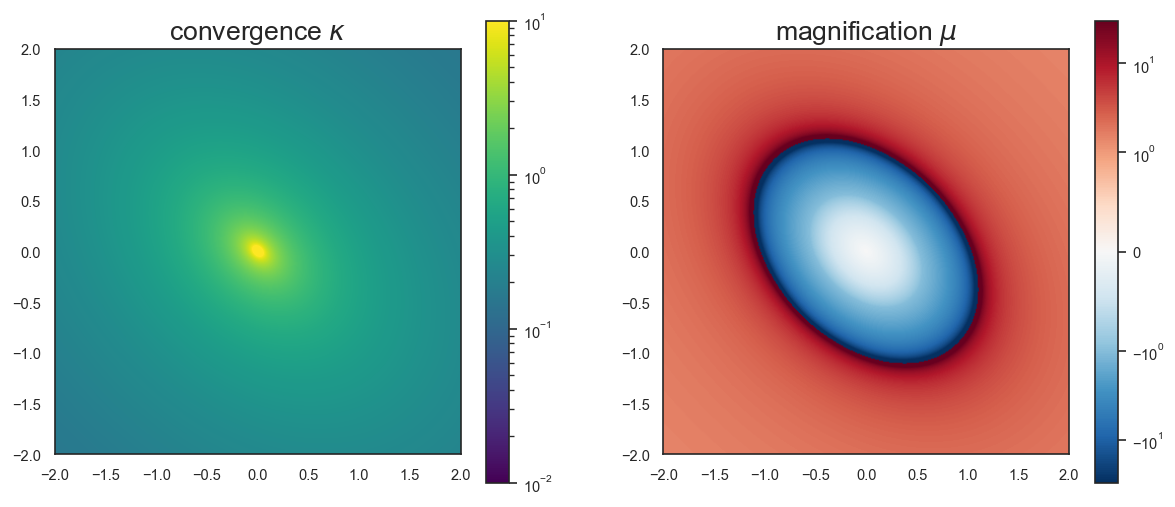

In [4]:
from matplotlib.colors import LogNorm, SymLogNorm

xy = gl.data.coordinate_grid(npix=400, deltapix=0.01)
with torch.no_grad():
    kappa = sie.kappa(xy[0], xy[1])
    mu    = sie.magnification(xy[0], xy[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(kappa.numpy(), origin='lower', cmap='viridis',
                     extent=(-2, 2, -2, 2),
                     norm=LogNorm(vmin=1e-2, vmax=10))
plt.colorbar(im0, ax=axes[0]); axes[0].set_title(r'convergence $\kappa$')
im1 = axes[1].imshow(mu.numpy(), origin='lower', cmap='RdBu_r',
                     extent=(-2, 2, -2, 2),
                     norm=SymLogNorm(linthresh=1, vmin=-30, vmax=30))
plt.colorbar(im1, ax=axes[1]); axes[1].set_title(r'magnification $\mu$')
plt.show()


## 4. Lens inversion from observed image positions

Given image positions (with measurement noise) we recover the SIE parameters by minimizing the source-plane scatter.

In [5]:
true_sie = gl.lens.SIE(theta_E=1.2, q=0.6, pa=np.pi/3)
beta_truth = (torch.tensor(0.05), torch.tensor(-0.08))
ximg, yimg = true_sie.solve_image_positions(*beta_truth, n_grid=4000)
ximg = ximg + torch.randn_like(ximg) * 0.01
yimg = yimg + torch.randn_like(yimg) * 0.01
print(f"observed {len(ximg)} images, sigma_pos = 0.01 arcsec")

class SIEInverse(nn.Module):
    def __init__(self):
        super().__init__()
        self.sie = gl.lens.SIE(theta_E=1.0, q=0.8, pa=0.5)
        self.beta = nn.Parameter(torch.zeros(2))
    def forward(self, dummy):
        bx, by = self.sie.ray_trace(ximg, yimg)
        return torch.stack([bx - self.beta[0], by - self.beta[1]])

model = SIEInverse()
target = torch.zeros(2, len(ximg))
res = gl.inference.fit(model, torch.tensor(0.), target, nn.MSELoss(),
                       lr=0.05, epochs=4000, lbfgs_polish=True,
                       scheduler=gl.inference.optimize.reduce_lr_on_plateau(patience=400))
print(gl.viz.diagnostics.format_summary({
    'final source-plane MSE': res.best_loss,
    'theta_E truth [arcsec]': float(true_sie.theta_E),
    'theta_E fit   [arcsec]': float(model.sie.theta_E),
    'q   truth'             : float(true_sie.q),
    'q   fit'               : float(model.sie.q),
    'pa  truth [rad]'       : float(true_sie.pa),
    'pa  fit   [rad]'       : float(model.sie.pa),
    'beta_x truth'          : float(beta_truth[0]),
    'beta_x fit'            : float(model.beta[0]),
    'beta_y truth'          : float(beta_truth[1]),
    'beta_y fit'            : float(model.beta[1]),
}, 'SIE inversion summary'))


observed 4 images, sigma_pos = 0.01 arcsec
=== SIE inversion summary ===
  final source-plane MSE :   +2.694e-06
  theta_E truth [arcsec] :         +1.2
  theta_E fit   [arcsec] :       +1.198
  q   truth              :         +0.6
  q   fit                :      +0.5883
  pa  truth [rad]        :       +1.047
  pa  fit   [rad]        :       +1.055
  beta_x truth           :        +0.05
  beta_x fit             :      +0.0503
  beta_y truth           :        -0.08
  beta_y fit             :      -0.0824


## 5. Validation — image-position residuals

After fitting, every observed image should ray-trace back
to the same source position β. The residual is
δβ = β_pred − β_true, in arcsec; a good fit has δβ
consistent with the assumed astrometric error (here we
injected σ_pos = 0.01 arcsec). We additionally check that
the **scatter across images** in the source plane matches
the propagated astrometric uncertainty.

In [6]:
with torch.no_grad():
    bx_pred, by_pred = model.sie.ray_trace(ximg, yimg)
dbx = bx_pred - float(beta_truth[0])
dby = by_pred - float(beta_truth[1])

# The lens equation is Jacobian-amplified: an astrometric
# error sigma_pos in the image plane produces a scatter
# ~ sigma_pos / sqrt(|mu|) in the source plane, but for SIE
# near the Einstein ring |mu| is comparable so a 0.01 arcsec
# input yields ~0.005-0.02 arcsec source-plane residuals.
print(gl.viz.diagnostics.format_summary({
    'mean   beta_x residual [arcsec]': float(dbx.mean()),
    'std    beta_x residual [arcsec]': float(dbx.std()),
    'mean   beta_y residual [arcsec]': float(dby.mean()),
    'std    beta_y residual [arcsec]': float(dby.std()),
    'rms    |dbeta|         [arcsec]': float(torch.sqrt((dbx**2+dby**2).mean())),
    'n images in fit'                : int(len(ximg)),
}, 'SIE inversion: image-position residuals'))


=== SIE inversion: image-position residuals ===
  mean   beta_x residual [arcsec] :   +0.0002987
  std    beta_x residual [arcsec] :    +0.002109
  mean   beta_y residual [arcsec] :      -0.0024
  std    beta_y residual [arcsec] :    +0.001655
  rms    |dbeta|         [arcsec] :    +0.003352
  n images in fit                 : 4


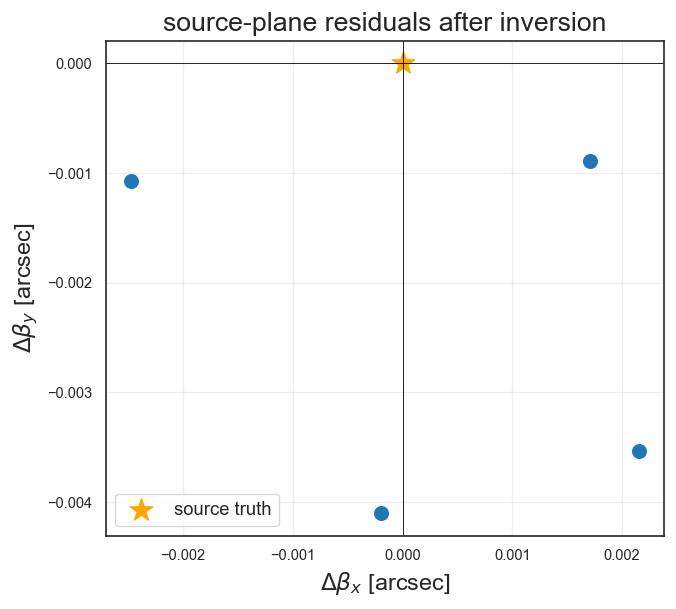

In [7]:
# Visualize the per-image residuals on the source plane.
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(dbx.numpy(), dby.numpy(), fmt='o', color='C0', ms=8,
            ecolor='gray', capsize=4)
ax.scatter([0], [0], marker='*', color='orange', s=200, label='source truth')
ax.set(xlabel=r'$\Delta\beta_x$ [arcsec]',
       ylabel=r'$\Delta\beta_y$ [arcsec]',
       title='source-plane residuals after inversion')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
plt.show()
